<a href="https://colab.research.google.com/github/ArhamAli80/Data-Portfolio/blob/main/Smart_Home_Intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client.session')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Loading the dataset
data = pd.read_csv("dataset_invade.csv")
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,No
1,0,udp,other,SF,146,0,0,0,0,0,...,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,No
2,0,tcp,private,S0,0,0,0,0,0,0,...,1.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,Yes
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.2,0.0,1.00,0.00,0.00,30,255,1.00,0.00,No
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                148517 non-null  int64  
 1   protocol_type           148517 non-null  object 
 2   service                 148517 non-null  object 
 3   flag                    148517 non-null  object 
 4   src_bytes               148517 non-null  int64  
 5   dst_bytes               148517 non-null  int64  
 6   land                    148517 non-null  int64  
 7   wrong_fragment          148517 non-null  int64  
 8   urgent                  148517 non-null  int64  
 9   hot                     148517 non-null  int64  
 10  logged_in               148517 non-null  int64  
 11  num_compromised         148517 non-null  int64  
 12  count                   148517 non-null  int64  
 13  srv_count               148517 non-null  int64  
 14  serror_rate         

### Dataset Column Descriptions

*   **duration**: Duration of the connection, offering insights into long-standing connections which may indicate data exfiltration or persistent attacks.
*   **protocol_type**: The protocol used for the connection, critical for understanding the nature of the traffic and identifying protocol-specific vulnerabilities.
*   **service**: Type of network service accessed, which can highlight targeted attacks on specific services within the smart home network.
*   **flag**: Status of the connection, useful for identifying anomalies in the expected behavior of network communications.
*   **src_bytes**: Volume of data sent from source to destination, aiding in the detection of large-scale data transfers or probing activities.
*   **dst_bytes**: Volume of data sent from destination back to source, potentially indicating responses to requests or data exfiltration attempts.
*   **land**: Indicates if the source and destination are the same, typically a sign of spoofing or reflection attacks.
*   **wrong_fragment**: Number of fragmented packets, which can be a tactic used in various attack vectors to bypass security measures.
*   **urgent**: Count of packets marked as urgent, a potential sign of attempts to prioritize malicious traffic.
*   **hot**: Indicates 'hot' indicators in the connection, often associated with exploits or unauthorized access attempts.
*   **logged_in**: Whether a user was successfully logged in, which can differentiate between legitimate user activity and unauthorized access.
*   **num_compromised**: The count of compromised conditions, pointing towards the severity of an intrusion or attack.
*   **count**: Number of connections to the same host, which can be indicative of scanning or flooding attacks.
*   **srv_count**: Number of connections to the same service, useful for identifying targeted attacks on specific services.
*   **serror_rate**: Rate of connections that resulted in SYN errors, highlighting potential SYN flood attacks.
*   **rerror_rate**: Rate of connections that resulted in reset errors, which can indicate interrupted connections or scanning attempts.
*   **same_srv_rate**: Proportion of connections to the same service, useful for detecting unusual access patterns.
*   **diff_srv_rate**: Rate of connections to different services, potentially indicative of port scanning or service enumeration activities.
*   **srv_diff_host_rate**: Rate of connections to different hosts for the same service, which can highlight distributed attack patterns.
*   **dst_host_count**: Count of connections to the same destination host, useful for analyzing targeted attacks on specific devices.
*   **dst_host_srv_count**: Number of connections to the same service on the destination host, offering insights into service-specific traffic patterns.
*   **dst_host_same_srv_rate**: Rate of connections to the same service on the destination host, important for identifying service-focused attacks.
*   **dst_host_diff_srv_rate**: Rate of connections to different services on the destination host, indicative of scanning or enumeration activities.
*   **attack**: Indicates whether the connection was part of an attack (Yes or No), serving as the label for model training.

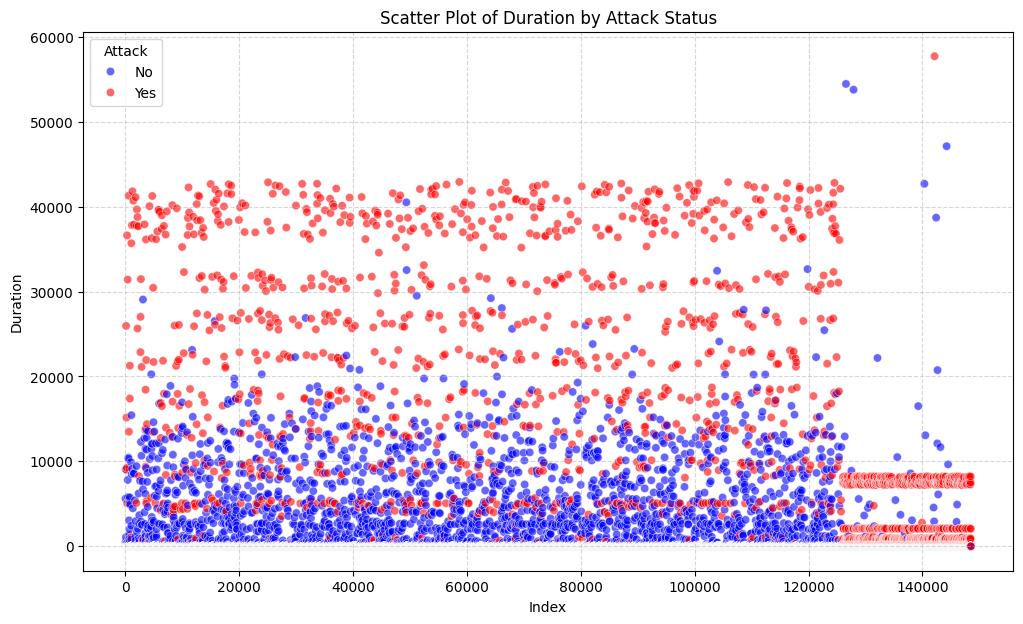

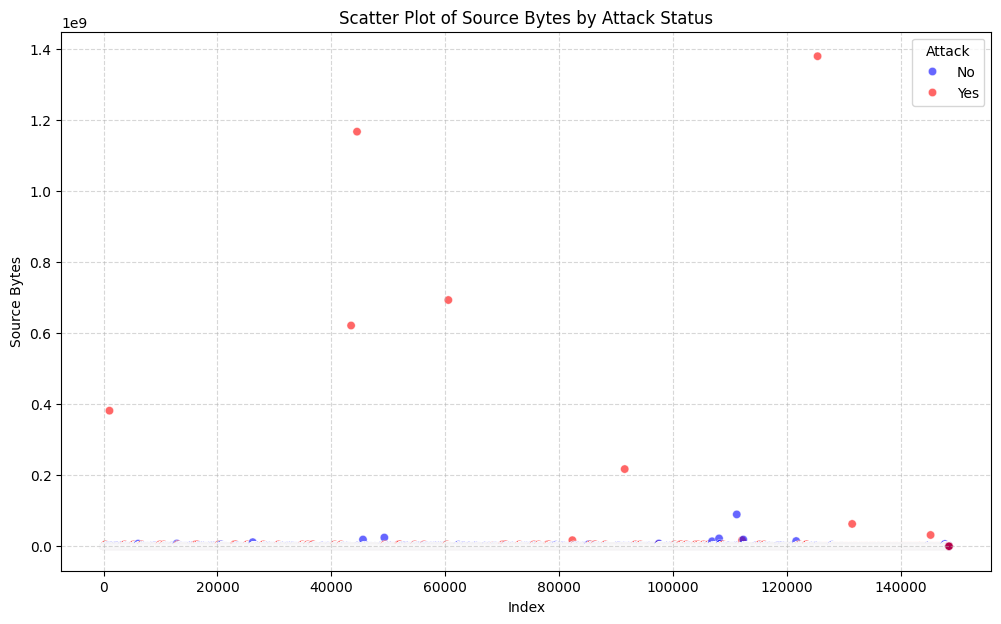

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for 'duration' with attack status
plt.figure(figsize=(12, 7))
sns.scatterplot(x=data['duration'].index, y=data['duration'], hue=data['attack'], palette={'Yes': 'red', 'No': 'blue'}, alpha=0.6)
plt.title('Scatter Plot of Duration by Attack Status')
plt.xlabel('Index')
plt.ylabel('Duration')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Attack')
plt.show()

# Scatter plot for 'src_bytes' with attack status
plt.figure(figsize=(12, 7))
sns.scatterplot(x=data['src_bytes'].index, y=data['src_bytes'], hue=data['attack'], palette={'Yes': 'red', 'No': 'blue'}, alpha=0.6)
plt.title('Scatter Plot of Source Bytes by Attack Status')
plt.xlabel('Index')
plt.ylabel('Source Bytes')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Attack')
plt.show()

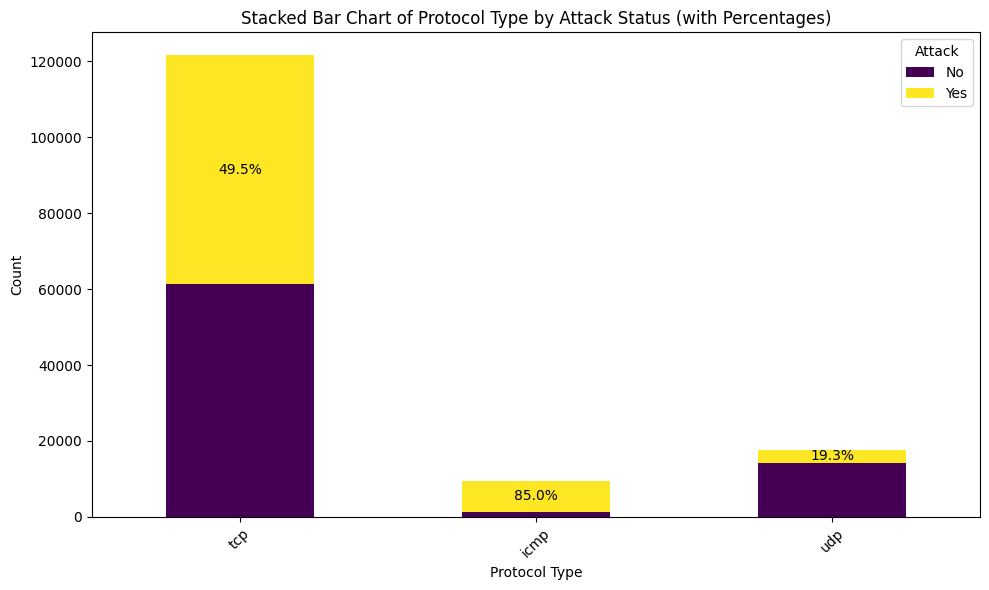

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a crosstab to count occurrences of each protocol type by attack status
protocol_attack_counts = pd.crosstab(data['protocol_type'], data['attack'])

# Sort by the number of 'Yes' attacks in descending order
protocol_attack_counts_sorted = protocol_attack_counts.sort_values(by='Yes', ascending=False)

# Calculate percentages for stacking
protocol_attack_percentages = protocol_attack_counts_sorted.div(protocol_attack_counts_sorted.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart (removed alpha=0.7 as per 'undo last step')
fig, ax = plt.subplots(figsize=(10, 6))
protocol_attack_counts_sorted.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

plt.title('Stacked Bar Chart of Protocol Type by Attack Status (with Percentages)')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Attack')
plt.tight_layout()

# Add percentage labels
for container in ax.containers:
    # Only show labels for 'Yes' attacks
    if container.get_label() == 'Yes':
        labels = [f'{w:.1f}%' for w in protocol_attack_percentages[container.get_label()]]
        for i, p in enumerate(container.patches):
            width = p.get_width()
            height = p.get_height()
            x, y = p.get_xy()

            if height > 0: # Only add label if the bar segment has height
                ax.text(x + width / 2,
                        y + height / 2,
                        labels[i],
                        ha='center',
                        va='center',
                        color='black', # Set color to black for 'Yes' attack labels
                        fontsize=10)
plt.show()

### Why ICMP and TCP Show High Attack Rates

*   **ICMP (Internet Control Message Protocol)**:
    *   **Reconnaissance**: ICMP is often used for network reconnaissance (e.g., ping sweeps to discover active hosts). Attackers use it to map network topologies and identify potential targets.
    *   **Denial of Service (DoS) Attacks**: ICMP can be exploited for various DoS attacks, such as ping floods (overwhelming a target with ICMP echo requests) or Smurf attacks (broadcasting ICMP requests to a network, causing all hosts to reply to a spoofed victim IP).
    *   **Low Overhead**: ICMP has a simple structure and low overhead, making it easy for attackers to generate a large volume of malicious traffic quickly.

*   **TCP (Transmission Control Protocol)**:
    *   **Ubiquity**: TCP is the backbone for most internet services (HTTP, HTTPS, FTP, SSH, etc.). Its widespread use makes it a primary target for attackers.
    *   **Connection-Oriented Nature**: The three-way handshake mechanism of TCP can be exploited. For example, in SYN flood attacks, an attacker sends numerous SYN requests without completing the handshake, exhausting the target server's resources.
    *   **Port Scanning**: Attackers often use TCP to perform port scans (e.g., SYN scans, connect scans) to discover open ports and services on a target system, looking for vulnerabilities.
    *   **Application-Layer Attacks**: Since many application-layer protocols run over TCP, attacks targeting these services (e.g., web application attacks, brute-force login attempts) are inherently TCP-based.

In [7]:
X = data.drop('attack', axis=1)
X_encoded = pd.get_dummies(X, columns=['protocol_type', 'service', 'flag'])


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

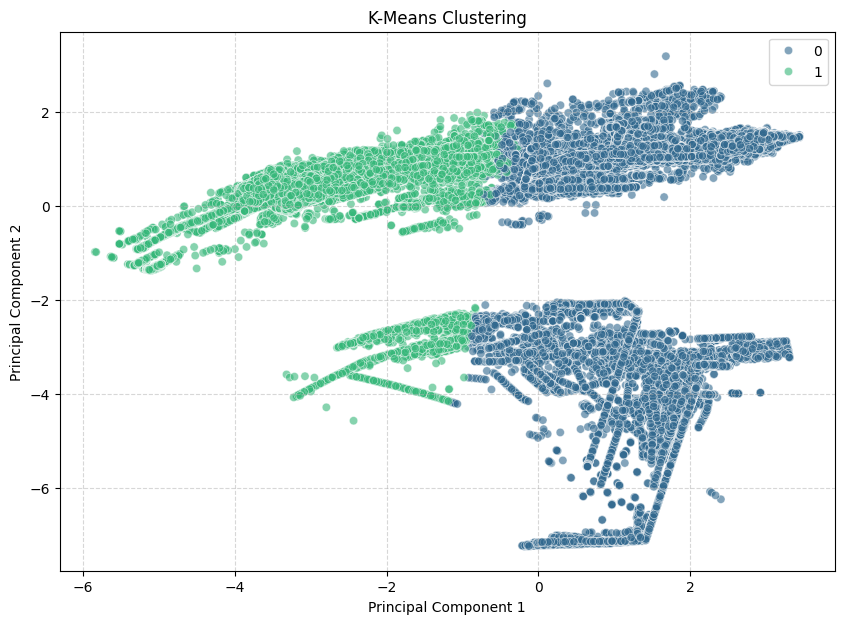

In [8]:
# Perform K-means clustering


# Reduce the encoded columns to 2 Principal Components for a 2D plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
plot_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
plot_df['Cluster'] = cluster_labels
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=plot_df, palette='viridis', alpha=0.6)


plt.title('K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [9]:
# Create a random forest classifier to detect whether incoming traffic is an attack or not
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Encode categorical variables
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop('attack_Yes', axis=1)  # Features
y = data_encoded['attack_Yes']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Initialize and train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=21)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9958591435496903


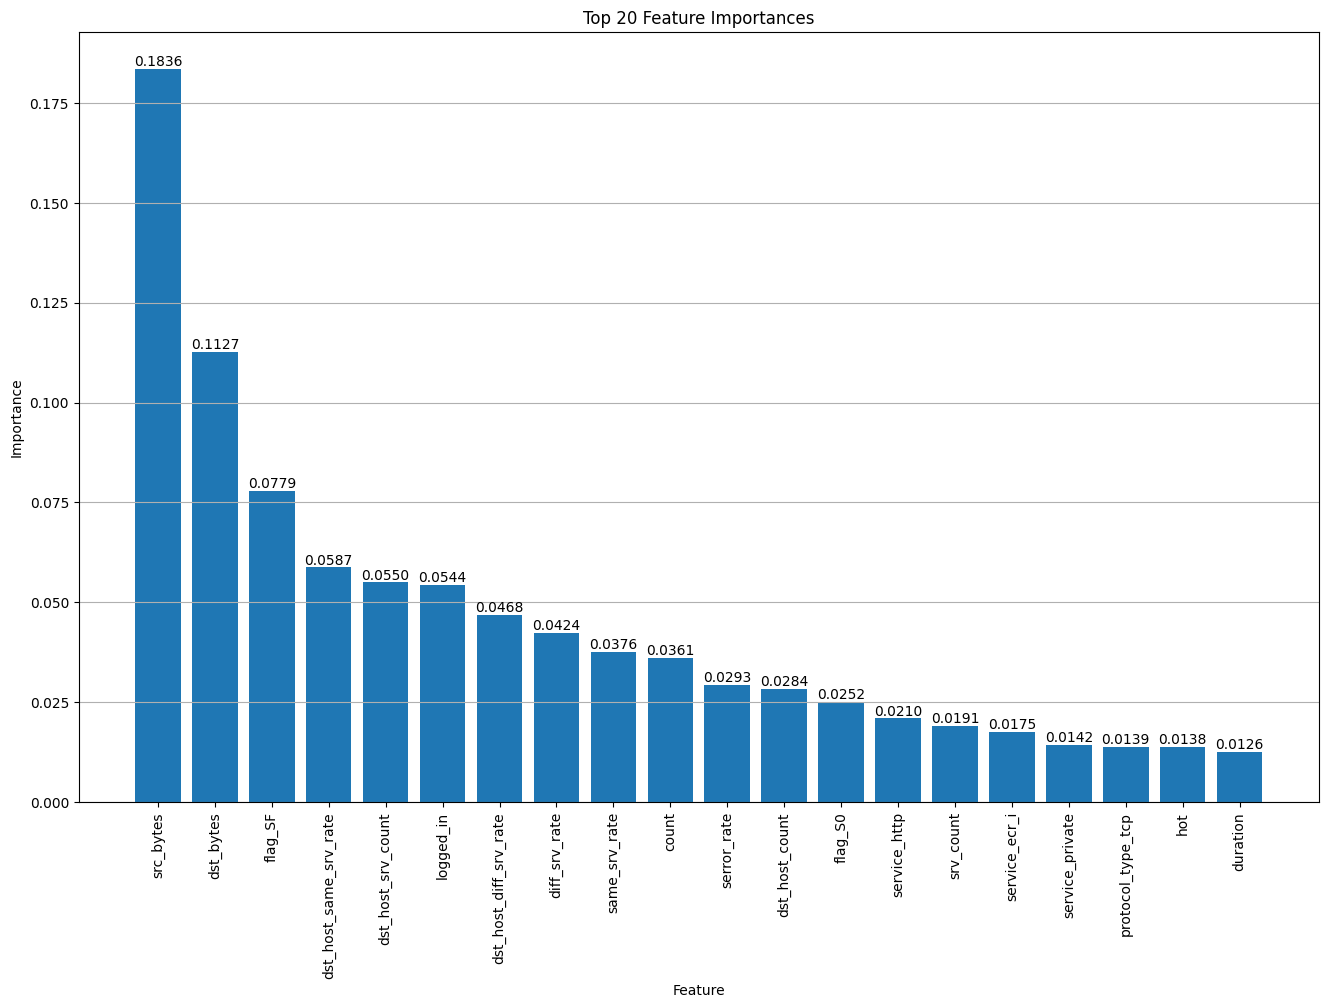

In [10]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf_classifier.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort feature importances in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Limit the number of features to be displayed
top_n = 20  # Specify the number of top features to display
top_features = feature_importance_df.head(top_n)

# Plot feature importances for top features with an increased figure size
plt.figure(figsize=(16, 10)) # Increased figure size
bars = plt.bar(top_features['Feature'], top_features['Importance'])

# Rotate feature labels
plt.xticks(rotation=90)

# Add gridlines
plt.grid(axis='y')

# Add numerical values on bars with limited decimal places
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(),
             f'{bar.get_height():.4f}',
             ha='center', va='bottom')

plt.ylabel('Importance')
plt.xlabel('Feature')
plt.title(f'Top {top_n} Feature Importances')
plt.show()

**Understanding The Features**

Based on the feature importance chart, these are the top 4 features that are likely to predict an attack, along with their meanings and why they are important:

*   **`src_bytes`**: Volume of data sent from source to destination. This is a strong predictor because unusually large or small volumes of data transferred from the source can indicate activities like data exfiltration (sending large amounts of sensitive data out) or probing/scanning attempts (very small or specific byte counts).

*   **`dst_bytes`**: Volume of data sent from destination back to source. High values here can signal that the target system is sending a lot of data back, which might be indicative of a successful data exfiltration by an attacker, or a large response to a malicious request.

*   **`flag_SF`**: This flag indicates a normal connection setup and termination ('SF' means connection established and finished without error). Its importance as a predictor suggests that many attacks involve *abnormal* connection states (e.g., partial connections, errors, or resets). Therefore, the absence or a low rate of 'SF' flags can be a strong indicator of malicious activity.

*   **`dst_host_same_srv_rate`**: The rate of connections to the same service on the destination host. This feature is important because a high rate might suggest a targeted attack on a specific service (like a denial-of-service attempt against a web server), while a very low rate could imply scanning across multiple services to find vulnerabilities.

**Comparing a Multi Layer Perceptron to a Random Forest Classifier**

In [11]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

#plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9677 - loss: 0.0874 - val_accuracy: 0.9790 - val_loss: 0.0577
Epoch 2/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9796 - loss: 0.0527 - val_accuracy: 0.9811 - val_loss: 0.0483
Epoch 3/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9820 - loss: 0.0452 - val_accuracy: 0.9828 - val_loss: 0.0481
Epoch 4/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9840 - loss: 0.0414 - val_accuracy: 0.9836 - val_loss: 0.0412
Epoch 5/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9847 - loss: 0.0394 - val_accuracy: 0.9848 - val_loss: 0.0387
Epoch 6/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9848 - loss: 0.0379 - val_accuracy: 0.9854 - val_loss: 0.0409
Epoch 7/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9857 - loss: 0.0373 - val_accuracy: 0.9845 - val_loss: 0.0422
Epoch 8/10
2971/2971 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9860 - loss: 0.0349 - 

929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


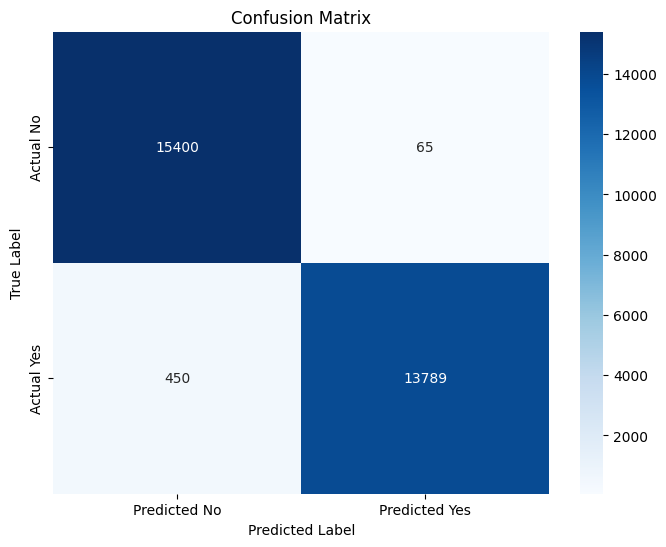

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Make predictions using the trained model
predictions = model.predict(X_test_scaled)

binary_predictions = (predictions > 0.8).astype(int)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, binary_predictions)

labelsX = ['Predicted No', 'Predicted Yes']
labelsY = ['Actual No','Actual Yes']

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labelsX, yticklabels=labelsY)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()